In [1]:
import sounddevice as sd
import numpy as np
import soundfile as sf
from src.audio_device import AudioDevice
from src.sharc import Sharc
import matplotlib.pyplot as plt
import librosa

In [2]:
print(sd.query_devices())

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Analogue 1 + 2 (8- Focusrite US, MME (8 in, 0 out)
   2 Microphone Array (Intel® Smart , MME (4 in, 0 out)
   3 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  4 Realtek HD Audio 2nd output (Re, MME (0 in, 2 out)
   5 Speakers (8- Focusrite USB Audi, MME (0 in, 8 out)
   6 Speakers (Realtek(R) Audio), MME (0 in, 2 out)
   7 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   8 Analogue 1 + 2 (8- Focusrite USB Audio), Windows DirectSound (8 in, 0 out)
   9 Microphone Array (Intel® Smart Sound Technology (Intel® SST)), Windows DirectSound (4 in, 0 out)
  10 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
  11 Realtek HD Audio 2nd output (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  12 Speakers (8- Focusrite USB Audio), Windows DirectSound (0 in, 8 out)
  13 Speakers (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  14 Speakers (8- Focusrite USB Audio), Windows WASAPI (0 in, 2 out)
  1

In [3]:
arthur, sr = sf.read('data/arthur_clip_48k.wav')

fs = 96_000
arthur_96 = librosa.resample(arthur, orig_sr=sr, target_sr=fs)


ad = AudioDevice(fs, in_device=1, out_device=4)

In [4]:
sharc = Sharc(arthur_96, ad)

In [5]:
sharc.no_cancel(n_repeats=1)


In [7]:
sharc.no_cancel(n_repeats=1)
sharc.no_cancel(n_repeats=2)
sharc.no_cancel(n_repeats=5)

In [21]:
sharc.cancel(n_repeats=1)


Overall ANC / No ANC: -22.91 dB


In [22]:
err = sharc.error_log
ref = sharc.ref_log

In [18]:
err_noise, ref_noise = sharc.ad.play(left=np.zeros_like(sharc.source))

In [17]:
np.max(np.abs(ref_noise)), np.max(np.abs(err_noise))

(np.float32(0.0007324219), np.float32(0.00036621094))

In [19]:
np.max(np.abs(ref_noise)), np.max(np.abs(err_noise))

(np.float32(0.00064086914), np.float32(0.00024414062))

In [23]:
print("Reference:")
print("  mean:       ", np.mean(ref))
print("  RMS:        ", np.sqrt(np.mean(ref**2)))
print("  mean square:", np.mean(ref**2))
print("  99th |x|:  ", np.percentile(np.abs(ref), 99))
print("  peak |x|:  ", np.max(np.abs(ref)))

print("Error:")
print("  RMS:        ", np.sqrt(np.mean(err**2)))
print("  mean square:", np.mean(err**2))
print("  99th |x|:  ", np.percentile(np.abs(err), 99))
print("  peak |x|:  ", np.max(np.abs(err)))

Reference:
  mean:        1.8786977e-05
  RMS:         0.01698189
  mean square: 0.00028838462
  99th |x|:   0.048950195
  peak |x|:   0.06802368
Error:
  RMS:         0.00039956786
  mean square: 1.5965448e-07
  99th |x|:   0.001373291
  peak |x|:   0.0031738281


Noise:
  mean:   1.854383488452882e-05
  median: 1.5381723642349243e-05
  1%:     9.527429938316345e-07
  5%:     2.2836029529571533e-06
  95%:    4.6358443796634674e-05
  99%:    6.498344242572785e-05
  min:    1.816079020500183e-07
  max:    0.00011077802628278732

No-cancel signal:
  mean:   0.14761994341884085
  median: 0.07476652413606644
  1%:     6.4420700073242195e-06
  5%:     2.2541731595993042e-05
  95%:    0.45548938028514385
  99%:    0.5600555719062686
  min:    4.1350722312927246e-07
  max:    0.7892589950934052



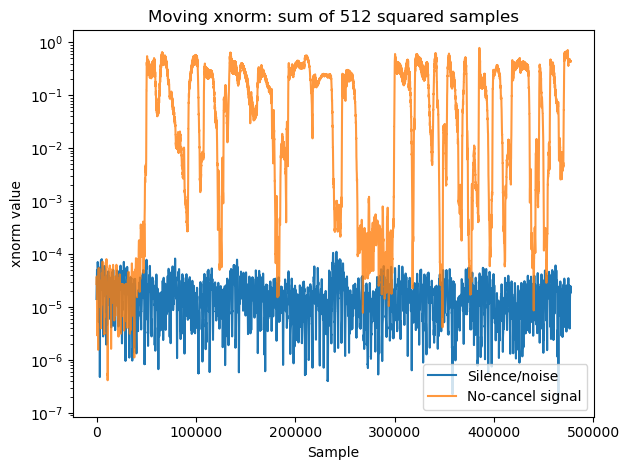

In [107]:
M = 512

def moving_xnorm(ref, M=512):
    ref = np.asarray(ref, dtype=np.float64)
    return np.convolve(ref**2, np.ones(M), mode="valid")

xnorm_noise = moving_xnorm(ref_noise, M)
xnorm_nocancel = moving_xnorm(ref, M)

for name, xnorm in [
    ("Noise", xnorm_noise),
    ("No-cancel signal", xnorm_nocancel),
]:
    print(f"{name}:")
    print("  mean:  ", np.mean(xnorm))
    print("  median:", np.median(xnorm))
    print("  1%:    ", np.percentile(xnorm, 1))
    print("  5%:    ", np.percentile(xnorm, 5))
    print("  95%:   ", np.percentile(xnorm, 95))
    print("  99%:   ", np.percentile(xnorm, 99))
    print("  min:   ", np.min(xnorm))
    print("  max:   ", np.max(xnorm))
    print()

plt.figure()
plt.title("Moving xnorm: sum of 512 squared samples")
plt.plot(xnorm_noise, label="Silence/noise")
plt.plot(xnorm_nocancel, label="No-cancel signal", alpha=0.8)
plt.yscale("log")
plt.xlabel("Sample")
plt.ylabel("xnorm value")
plt.legend()
plt.tight_layout()
plt.show()

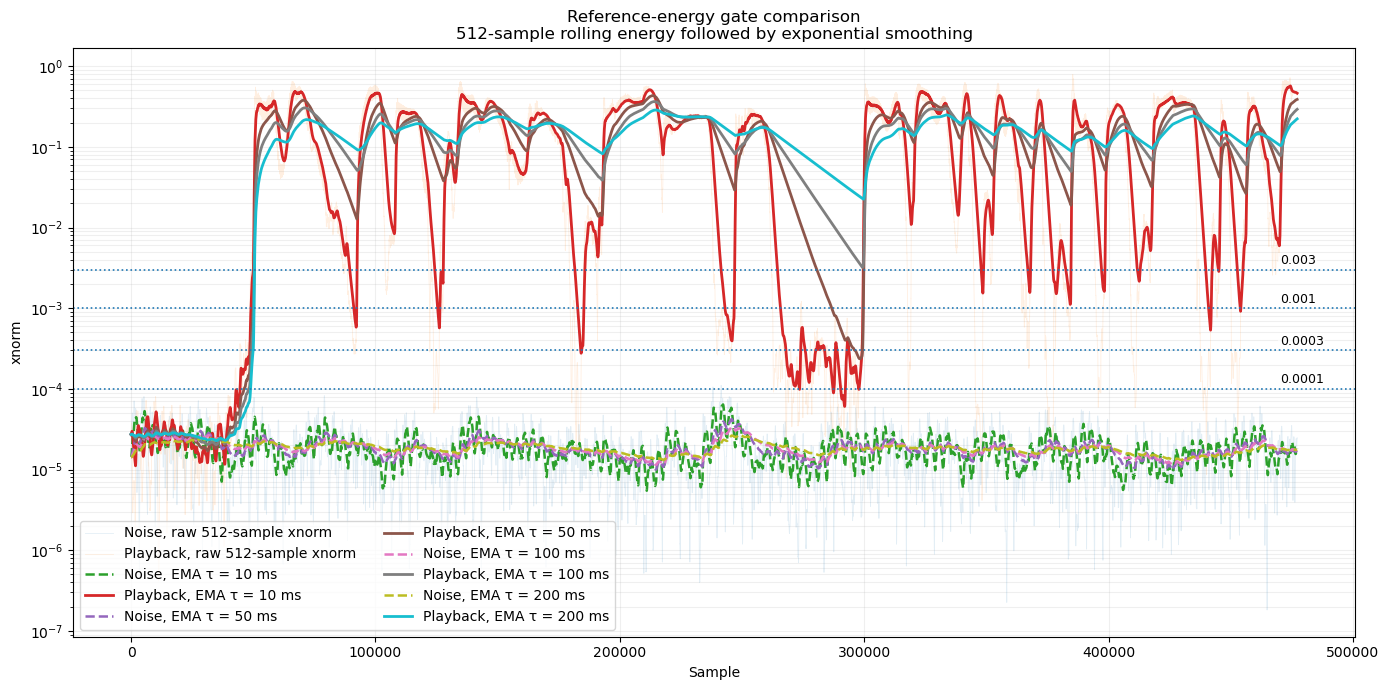

In [119]:
import numpy as np
import matplotlib.pyplot as plt

M = 512
fs = 96_000

def moving_xnorm(ref, M=512):
    ref = np.asarray(ref, dtype=np.float64)
    return np.convolve(ref**2, np.ones(M), mode="valid")

def ema(x, tau_s, fs=96_000):
    alpha = np.exp(-1.0 / (fs * tau_s))

    y = np.empty_like(x)
    y[0] = x[0]

    for i in range(1, len(x)):
        y[i] = alpha * y[i - 1] + (1.0 - alpha) * x[i]

    return y


xnorm_noise = moving_xnorm(ref_noise, M)
xnorm_signal = moving_xnorm(ref, M)

time_constants = {
    "10 ms": 0.010,
    "50 ms": 0.050,
    "100 ms": 0.100,
    "200 ms": 0.200,
}

thresholds = [1e-4, 3e-4, 1e-3, 3e-3]

fig, ax = plt.subplots(figsize=(14, 7))

# Raw traces in the background
ax.plot(
    xnorm_noise,
    linewidth=0.6,
    alpha=0.12,
    label="Noise, raw 512-sample xnorm"
)

ax.plot(
    xnorm_signal,
    linewidth=0.6,
    alpha=0.12,
    label="Playback, raw 512-sample xnorm"
)

# Smoothed traces
for label, tau in time_constants.items():
    ax.plot(
        ema(xnorm_noise, tau, fs),
        linestyle="--",
        linewidth=1.8,
        label=f"Noise, EMA τ = {label}"
    )

    ax.plot(
        ema(xnorm_signal, tau, fs),
        linewidth=2.0,
        label=f"Playback, EMA τ = {label}"
    )

# Threshold lines and direct labels
x_label = len(xnorm_signal) * 0.985

for threshold in thresholds:
    ax.axhline(
        threshold,
        linestyle=":",
        linewidth=1.2
    )

    ax.text(
        x_label,
        threshold * 1.08,
        f"{threshold:g}",
        ha="left",
        va="bottom",
        fontsize=9,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.75,
            "pad": 1
        }
    )

# ax.text(
#     x_label,
#     thresholds[-1] * 1.75,
#     "Adaptation thresholds",
#     ha="right",
#     va="bottom",
#     fontsize=9
# )

ax.set_yscale("log")
ax.set_xlabel("Sample")
ax.set_ylabel("xnorm")
ax.set_title(
    "Reference-energy gate comparison\n"
    "512-sample rolling energy followed by exponential smoothing"
)

ax.grid(True, which="both", alpha=0.2)
ax.legend(ncol=2, loc="lower left")
fig.tight_layout()
plt.show()

In [118]:
def alpha(tau_ms):
    return np.exp(-1000 / (fs * tau_ms))

alpha(10), alpha(50), alpha(100), alpha(200)

(np.float64(0.9989588756797245),
 np.float64(0.9997916883665486),
 np.float64(0.9998958387584922),
 np.float64(0.9999479180229799))

In [42]:
sharc.no_cancel(2)
sharc.no_cancel(5)

Overall ANC / No ANC: 0.76 dB


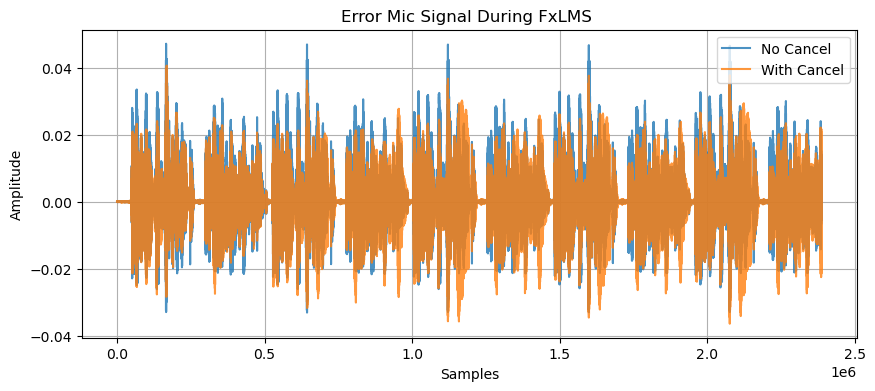

In [106]:
sharc.cancel(5)
sharc.plot_error_mic()
# sharc.plot_error_ratio()

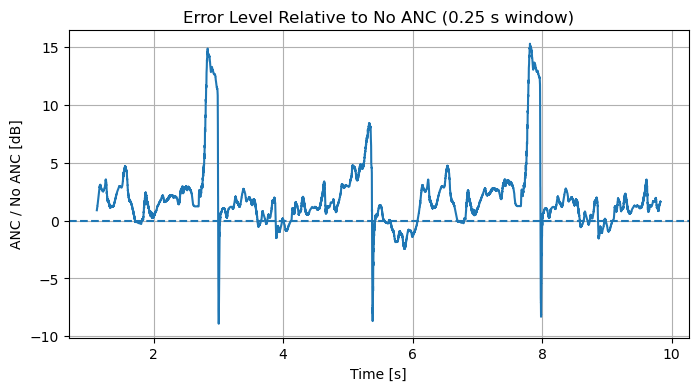

In [96]:
sharc.plot_error_ratio()

In [14]:
err = sharc.error_log
nc = sharc.no_cancels[sharc.n_repeats]

print(np.mean(err**2))
print(np.mean(nc**2))
print(np.sqrt(np.mean(err**2)))
print(np.sqrt(np.mean(nc**2)))

4.903502e-05
3.0963576e-05
0.0070025013
0.0055644927


In [18]:
nc.min()

np.float32(-0.033233643)

Overall ANC / No ANC: 13.61 dB


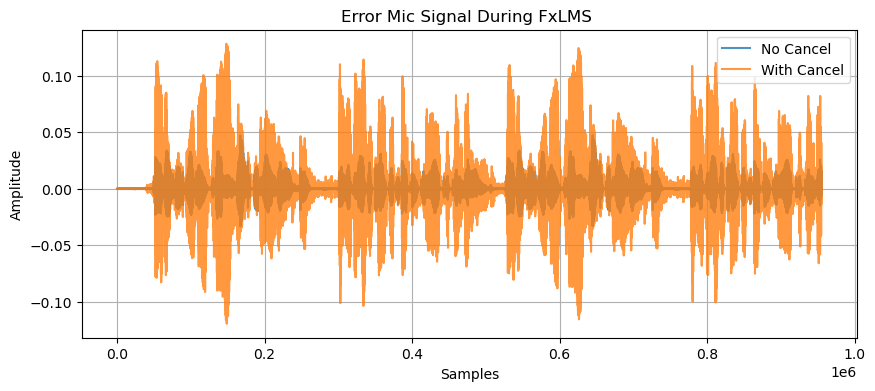

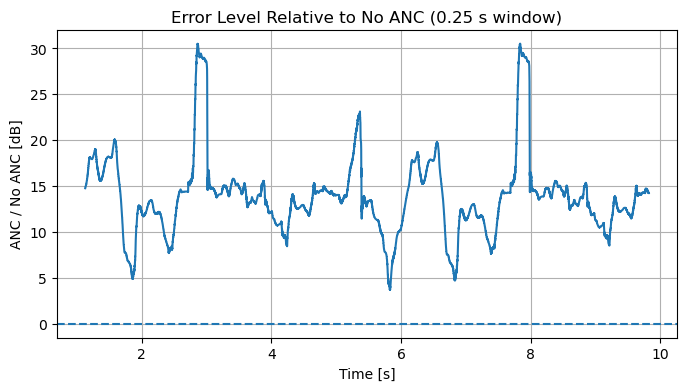

In [17]:
sharc.cancel(2)
sharc.plot_error_mic()
sharc.plot_error_ratio()